## Exercise in Photogrammetry I
## **Ex.4 : Binary Images**
### Hand out: xx.xx.xxxx 
### Submission: xx.xx.xxxx 
### Points: 30

## A. Binary Images and Connected Components *(18 points)*

In this task you will learn how to **convert grayscale** images to **binary** images by applying a certain **thresold**. Finally, based on the binary image we can **identify** which **components** are connected to compute the **number of objects** in the image.

**Tasks:**
1. Load the grayscale image ```shapes.png``` from disk and print its minimum and maximum value. Finally, visualize the grayscale image. *(0.5 points)*
2. Convert the grayscale image to a binary image by applying a threshold of $T=100$. Make sure that all pixels > T have an intensity value of 1 (foreground) and all other pixels have an intensity value of 0 (background). Print the minimum and maximum value of your converted image. Finally, visualize the binary image. *(1.5 points)*
3. In the lecture you discussed two algorithms to identify connected components in a binary image. Implement the *Connected Components for Grids* algorithm and apply it to the previous defined binary image by following each step outlined below:
    - Write a function called ```connected_components(binary_img, neighborhood)``` which computes the *components image* for either *N4 neighborhood* or *N8 neighborhood* **but** does not apply the *equivalence graph* (see *Algorithm 1 in lecture*). Do not use any external python functions which compute the *components image* for you.  *(8 points)*
      <br> **Hint:** Write functions to get the *N4* and *N8 neighborhood* since this operation will be used in other tasks as well
      
    - Apply your function to the binary image and visualize your result for *N4 neighborhood* and *N8 neighborhood*. *(2 points)*
    - Apply the *equivalence graph* to the *components image* and visualize your result for *N4 neighborhood* and *N8 neighborhood*. *(4 points)*
    - Finally, print the number of components in the binary image for *N4 neighborhood* and *N8 neighborhood*. If there is any difference explain why this is the case. *(2 points)*
    

In [65]:
# import all required modules
import cv2
import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt
import random
import skimage

### A1

In [3]:
# Load the grayscale image
img = cv2.imread('./images/shapes.png', cv2.IMREAD_GRAYSCALE)

In [5]:
# Print the minimum and maximum value of the grayscale image
np.min(img), np.max(img)

(0, 180)

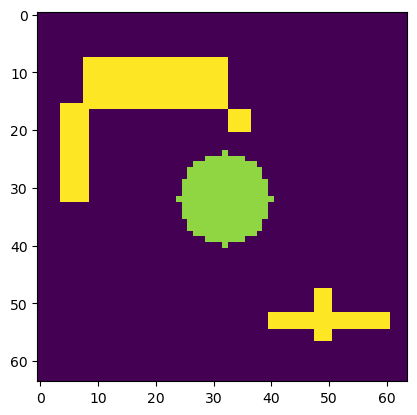

In [7]:
# Visualize the grayscale image
plt.imshow(img)
plt.show()

### A2

In [9]:
# Convert the grayscale image to a binary image {0,1}
im_bw = cv2.threshold(img, 100, 1, cv2.THRESH_BINARY)[1]

In [11]:
# Print the minimum and maximum value of the binary image
np.min(im_bw), np.max(im_bw)

(0, 1)

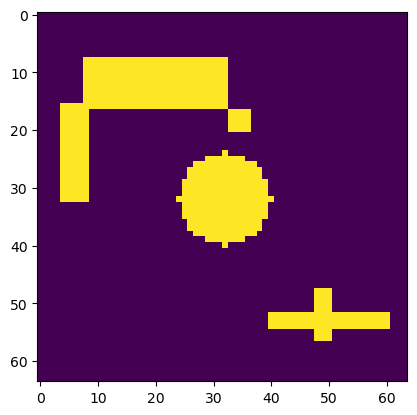

In [13]:
# Visualize the binary image
plt.imshow(im_bw)
plt.show()

### A3

In [13]:
# Write a function called connected_components(binary_img, neighborhood)
def connected_components(binary_img, neighborhood):
    
    connected_image = np.zeros(np.shape(binary_img))
    S = []
    K = 0
    for i in range(200):
        x_idx = random.choice(np.arange(np.shape(binary_img)[0]))
        y_idx = random.choice(np.arange(np.shape(binary_img)[1]))
    
        if connected_image[x_idx,y_idx] == 0 and binary_img[x_idx,y_idx] == 1:
            S.append([x_idx,y_idx])
            K = K + 1
            connected_image[x_idx,y_idx] = K
            
            for index in S:
                
                x_idx = index[0]
                y_idx = index[1]
                
                if neighborhood == 4:
            
                    if x_idx-1 >= 0:
                
                        if binary_img[x_idx-1,y_idx] == 1 and connected_image[x_idx-1,y_idx] == 0:
                    
                            connected_image[x_idx-1,y_idx] = K
                    
                            S.append([x_idx-1,y_idx])
                    
                    if x_idx+1 < np.shape(binary_img)[0]:
                
                        if binary_img[x_idx+1,y_idx] == 1 and connected_image[x_idx+1,y_idx] == 0:
                    
                            connected_image[x_idx+1,y_idx] = K
                    
                            S.append([x_idx+1,y_idx])
                    
                    if y_idx-1 >= 0:
                
                        if binary_img[x_idx,y_idx-1] == 1 and connected_image[x_idx,y_idx-1] == 0:
                    
                            connected_image[x_idx,y_idx-1] = K
                    
                            S.append([x_idx,y_idx-1])
                    
                    if y_idx+1 < np.shape(binary_img)[1]:
                
                        if binary_img[x_idx,y_idx+1] == 1 and connected_image[x_idx,y_idx+1] == 0:
                    
                            connected_image[x_idx,y_idx+1] = K
                                
                            S.append([x_idx,y_idx+1])
            
                if neighborhood == 8:
                    
                    if x_idx-1 >= 0 and y_idx+1 < np.shape(binary_img)[1]:
                        
                        if binary_img[x_idx-1,y_idx+1] == 1 and connected_image[x_idx-1,y_idx+1] == 0:
                            
                            connected_image[x_idx-1,y_idx+1] = K
                            
                            S.append([x_idx-1,y_idx+1])
                            
                    if x_idx+1 < np.shape(binary_img)[0] and y_idx+1 < np.shape(binary_img)[1]:
                        
                        if binary_img[x_idx+1,y_idx+1] == 1 and connected_image[x_idx+1,y_idx+1] == 0:
                            
                            connected_image[x_idx+1,y_idx+1] = K
                            
                            S.append([x_idx+1,y_idx+1])
                            
                    if x_idx-1 >= 0 and y_idx-1 >= 0:
                        
                        if binary_img[x_idx-1,y_idx-1] == 1 and connected_image[x_idx-1,y_idx-1] == 0:
                            
                            connected_image[x_idx-1,y_idx-1] = K
                            
                            S.append([x_idx-1,y_idx-1])
                            
                    if x_idx+1 < np.shape(binary_img)[0] and y_idx-1 >= 0:
                        
                        if binary_img[x_idx+1,y_idx-1] == 1 and connected_image[x_idx+1,y_idx-1] == 0:
                            
                            connected_image[x_idx+1,y_idx-1] = K
                            
                            S.append([x_idx+1,y_idx-1])
            
                    if x_idx-1 >= 0:
                
                        if binary_img[x_idx-1,y_idx] == 1 and connected_image[x_idx-1,y_idx] == 0:
                    
                            connected_image[x_idx-1,y_idx] = K
                    
                            S.append([x_idx-1,y_idx])
                    
                    if x_idx+1 < np.shape(binary_img)[0]:
                
                        if binary_img[x_idx+1,y_idx] == 1 and connected_image[x_idx+1,y_idx] == 0:
                    
                            connected_image[x_idx+1,y_idx] = K
                    
                            S.append([x_idx+1,y_idx])
                    
                    if y_idx-1 >= 0:
                
                        if binary_img[x_idx,y_idx-1] == 1 and connected_image[x_idx,y_idx-1] == 0:
                    
                            connected_image[x_idx,y_idx-1] = K
                    
                            S.append([x_idx,y_idx-1])
                    
                    if y_idx+1 < np.shape(binary_img)[1]:
                
                        if binary_img[x_idx,y_idx+1] == 1 and connected_image[x_idx,y_idx+1] == 0:
                    
                            connected_image[x_idx,y_idx+1] = K
                                
                            S.append([x_idx,y_idx+1])
            
                    
                    
    return K, connected_image  

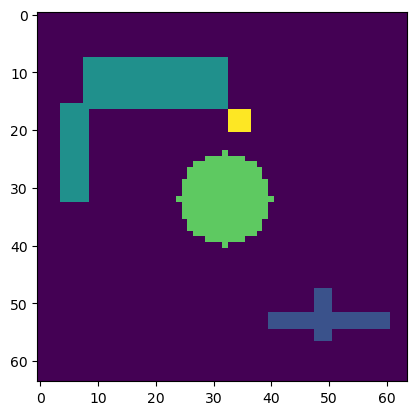

In [14]:
# Compute the components image with N4 Neighborhood and visualize your result
K, c_im = connected_components(im_bw, 4)
plt.imshow(c_im)
plt.show()

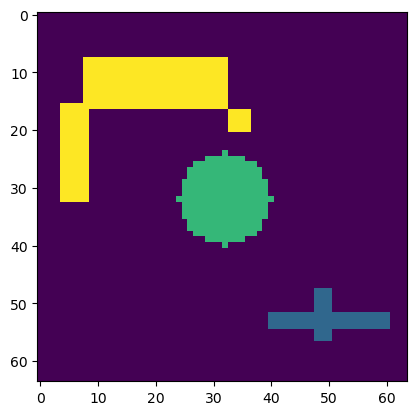

In [15]:
# Compute the components image with N8 Neighborhood and visualize your result
K, c_im = connected_components(im_bw, 8)
plt.imshow(c_im)
plt.show()

In [193]:
def find(l,target): # function to find a component value in the equivalence table
    for i,lst in enumerate(l):
        for j,num in enumerate(lst):
            if num == target:
                return (i, j)
    return (None, None)

In [195]:
# Apply the equivalence graph to your components image with N4 Neighborhood and visualize your result
def equivalence_graph(binary_img, neighborhood):

    connected_image = np.zeros(np.shape(binary_img)) # image to get output as component image
    K = 0 # number of components
    et = [] # equivalence table

    for row in range(np.shape(binary_img)[0]): # loop over each row of the image
        for col in range(np.shape(binary_img)[1]): # loop over each column of the image

            nc = [] # maintaining components of the neighbors

            if binary_img[row,col] == 1: # its a foreground pixel

                if neighborhood == 4:

                    if col-1 >= 0 and binary_img[row,col-1] == 1: # check left pixel

                        clp = connected_image[row,col-1] # get component of left pixel

                        nc.append(clp) # storing component of left pixel

                    if row-1 >= 0 and binary_img[row-1,col] == 1: # check the pixel above

                        cap = connected_image[row-1,col] # get component of the pixel above

                        nc.append(cap)

                    if len(nc) == 0: # if there are no neighbors

                        K = K+1 # start a new component

                        connected_image[row,col] = K # assign the new component

                    if len(nc) == 1: # if there is only 1 neighbor

                        connected_image[row,col] = nc[0] # assign the same label

                    if len(nc) == 2: # if there are 2 neighbors

                        if nc[0] == nc[1]: # if both have the same component

                            connected_image[row,col] = nc[0] # assign any of the label

                        if nc[0] != nc[1]: # if both components are different

                            connected_image[row,col] = min(nc) # assign the minimum of the two components

                            l_index_1 = find(et,nc[0]) # check if the first component is already available in the equivalence table
                            l_index_2 = find(et,nc[1]) # check if the second component is already available in the equivalence table

                            if l_index_1 == l_index_2 == (None, None): # if both components are not present in the equivalence table

                                et.append([nc[0],nc[1]]) # add both components in the equivalence table

                            if l_index_1 != (None, None) and l_index_2 == (None, None): # first component is available in the equivalence table

                                et[l_index_1[0]].append(nc[1]) # add the second component in the equivalence table

                            if l_index_1 == (None, None) and l_index_2 != (None, None): # second component is available in the equivalence table

                                et[l_index_2[0]].append(nc[0]) # add the first component in the equivalence table

                if neighborhood == 8:

                    if col-1 >= 0 and binary_img[row,col-1] == 1: # check left pixel

                        clp = connected_image[row,col-1] # get component of left pixel

                        nc.append(clp) # storing component of left pixel

                    if row-1 >= 0 and binary_img[row-1,col] == 1: # check the pixel above

                        cap = connected_image[row-1,col] # get component of the pixel above

                        nc.append(cap) # storing component of above pixel

                    if row-1 >= 0 and col-1 >= 0 and binary_img[row-1,col-1] == 1: # check the picel left above

                        clap = connected_image[row-1,col-1] # get component of the pixel left above

                        nc.append(clap) # storing component of left above pixel

                    if row-1 >= 0 and col+1 < np.shape(binary_img)[1] and binary_img[row-1,col+1] == 1: # check the pixel right above

                        crap = connected_image[row-1,col+1] # get component of the pixel right above

                        nc.append(crap) # storing component of right above pixel

                    if len(nc) == 0: # if there are no neighbors

                        K = K+1 # start a new component

                        connected_image[row,col] = K # assign the new component

                    if len(nc) == 1: # if there is only 1 neighbor

                        connected_image[row,col] = nc[0] # assign the same label

                    if len(nc) == 2: # if there are 2 neighbors

                        if nc[0] == nc[1]: # if both have the same component

                            connected_image[row,col] = nc[0] # assign any of the label

                        if nc[0] != nc[1]: # if both components are different

                            connected_image[row,col] = min(nc) # assign the minimum of the two components

                            l_index_1 = find(et,nc[0]) # check if the first component is already available in the equivalence table
                            l_index_2 = find(et,nc[1]) # check if the second component is already available in the equivalence table

                            if l_index_1 == l_index_2 == (None, None): # if both components are not present in the equivalence table

                                et.append([nc[0],nc[1]]) # add both components in the equivalence table

                            if l_index_1 != (None, None) and l_index_2 == (None, None): # first component is available in the equivalence table

                                et[l_index_1[0]].append(nc[1]) # add the second component in the equivalence table

                            if l_index_1 == (None, None) and l_index_2 != (None, None): # second component is available in the equivalence table

                                et[l_index_2[0]].append(nc[0]) # add the first component in the equivalence table

                    if len(nc) == 3: # if there are 3 neighbors

                        if nc[0] == nc[1] == nc[2]: # if all 3 neighbors have the same component

                            connected_image[row,col] = nc[0] # assign any of the label

                        else:

                            connected_image[row,col] = min(nc) # assign the minimum of the three components

                            l_index_1 = find(et,nc[0]) # check if the first component is already available in the equivalence table
                            l_index_2 = find(et,nc[1]) # check if the second component is already available in the equivalence table
                            l_index_3 = find(et,nc[2]) # check if the third component is already available in the equivalence table

                            if l_index_1 == l_index_2 == l_index_3 == (None, None): # all 3 components are not available in the equivalence table

                                et.append([nc[0],nc[1],nc[2]]) # add all 3 components in the equivalence table

                            if l_index_1 != (None, None) and l_index_2 == l_index_3 == (None, None): # if only first component is available in the equivalence table

                                et[l_index_1[0]].append(nc[1]) # add the second component in the equivalence table

                                et[l_index_1[0]].append(nc[2]) # add the third component in the equivalence table

                            if l_index_1 != (None, None) and l_index_2 != (None, None) and l_index_3 == (None, None): # if first 2 components are available in the equivalence table

                                et[l_index_1[0]].append(nc[2]) # add the third component in the equivalence table by using any of the available component indexes


                            if l_index_1 == l_index_3 != (None, None) and l_index_2 == (None, None): # if first and 3rd components are available in the equivalence table

                                et[l_index_1[0]].append(nc[1]) # add the second component in the equivalence table by using any of the available component indexes

                            if l_index_1 == l_index_3 == (None, None) and l_index_2 != (None, None): # if 1st and 3rd components are not available in the equivalence table

                                et[l_index_2[0]].append(nc[0]) # add the first component in the equivalence table by using the 2nd
                                et[l_index_2[0]].append(nc[2]) # add the third component in the equivalence table by using the second

                            if l_index_2 == l_index_1 != (None, None) and l_index_3 == (None, None): # if 3rd component is not available in the equivalence table

                                et[l_index_2[0]].append(nc[2]) # add the third component in the equivalence table by using any of the first 2

                            if l_index_2 == l_index_3 != (None, None) and l_index_1 == (None, None): # if 1st component is not available in the equivalence table

                                et[l_index_2[0]].append(nc[0]) # add the first component in the equivalence table by using any of the second or 3rd

                    if len(nc) == 4: # if there are 4 neighbors

                        if nc[0] == nc[1] == nc[2] == nc[3]: # all 4 neighbors are the same

                            connected_image[row,col] = nc[0] # assign any of the label

                        else:

                            connected_image[row,col] = min(nc) # assign the minimum of the 4 components

                            l_index_1 = find(et,nc[0]) # check if the first component is already available in the equivalence table
                            l_index_2 = find(et,nc[1]) # check if the second component is already available in the equivalence table
                            l_index_3 = find(et,nc[2]) # check if the third component is already available in the equivalence table
                            l_index_4 = find(et,nc[3]) # check if the fourth component is already available in the equivalence table

                            if l_index_1 == l_index_2 == l_index_3 == l_index_4 == (None, None): # all 4 components are not available in the equivalence table

                                et.append([nc[0],nc[1],nc[2],nc[3]]) # add all 4 components in the equivalence table

                            if l_index_1 == l_index_2 == l_index_3 == (None, None) and l_index_4 != (None, None): # if first 3 components are not available in the equivalence table

                                et[l_index_4[0]].append(nc[0]) # add the first component in the equivalence table
                                et[l_index_4[0]].append(nc[1]) # add the second component in the equivalence table
                                et[l_index_4[0]].append(nc[2]) # add the third component in the equivalence table

                            if l_index_1 == l_index_2 == l_index_4 == (None, None) and l_index_3 != (None, None): # if only 3rd component is present in the equivalence table

                                et[l_index_3[0]].append(nc[0]) # add the first component in the equivalence table
                                et[l_index_3[0]].append(nc[1]) # add the second component in the equivalence table
                                et[l_index_3[0]].append(nc[3]) # add the fourth component in the equivalence table

                            if l_index_1 == l_index_2 == (None, None) and l_index_3 == l_index_4 != (None, None): # if first 2 components are not available in the equivalence table

                                et[l_index_4[0]].append(nc[0]) # add the first component in the equivalence table
                                et[l_index_4[0]].append(nc[1]) # add the second component in the equivalence table

                            if l_index_1 == l_index_3 == l_index_4 == (None, None) and l_index_2 != (None, None): # if only 2nd component is present in the equivalence table

                                et[l_index_2[0]].append(nc[0]) # add the first component in the equivalence table
                                et[l_index_2[0]].append(nc[2]) # add the third component in the equivalence table
                                et[l_index_2[0]].append(nc[3]) # add the fourth component in the equivalence table

                            if l_index_1 == l_index_3 == (None,None) and l_index_2 == l_index_4 != (None, None): # if only 2nd and 4th components are available in the equivalence table

                                et[l_index_4[0]].append(nc[0]) # add the first component in the equivalence table
                                et[l_index_4[0]].append(nc[2]) # add the third component in the equivalence table

                            if l_index_1 == l_index_4 == (None, None) and l_index_2 == l_index_3 != (None, None): # if only 2nd and 3rd components are available in the equivalence table

                                et[l_index_3[0]].append(nc[0]) # add the first component in the equivalence table
                                et[l_index_3[0]].append(nc[3]) # add the fourth component in the equivalence table  

                            if l_index_1 == (None, None) and l_index_2 == l_index_3 == l_index_4 != (None, None): # if last 3 components are available in the equivalence table

                                et[l_index_4[0]].append(nc[0]) # add the first component in the equivalence table

                            if l_index_1 != (None, None) and l_index_2 == l_index_3 == l_index_4 == (None, None): # if only first component is present in the equivalence table

                                et[l_index_1[0]].append(nc[1]) # add the second component in the equivalence table
                                et[l_index_1[0]].append(nc[2]) # add the third component in the equivalence table
                                et[l_index_1[0]].append(nc[3]) # add the fourth component in the equivalence table

                            if l_index_1 == l_index_4 != (None, None) and l_index_2 == l_index_3 == (None, None): # if only 1st and 4th components are available in the equivalence table

                                et[l_index_4[0]].append(nc[1]) # add the second component in the equivalence table
                                et[l_index_4[0]].append(nc[2]) # add the third component in the equivalence table

                            if l_index_1 == l_index_3 != (None, None) and l_index_2 == l_index_4 == (None, None): # if only 1st and 3rd components are available in the equivalence table

                                et[l_index_1[0]].append(nc[1]) # add the second component in the equivalence table
                                et[l_index_1[0]].append(nc[3]) # add the fourth component in the equivalence table

                            if l_index_1 == l_index_3 == l_index_4 != (None, None) and l_index_2 == (None, None): # if only 2nd component is not available in the equivalence table

                                et[l_index_4[0]].append(nc[1]) # add the second component in the equivalence table

                            if l_index_1 == l_index_2 != (None, None) and l_index_3 == l_index_4 == (None, None): # if only 1st and 2nd components are available in the equivalence table

                                et[l_index_1[0]].append(nc[2]) # add the 3rd component in the equivalence table
                                et[l_index_1[0]].append(nc[3]) # add the 4th component in the equivalence table
                                
                            if l_index_1 == l_index_2 == l_index_4 != (None, None) and l_index_3 == (None, None): # if only 3rd component is not available in the equivalence table

                                et[l_index_4[0]].append(nc[2]) # add the third component in the equivalence table

                            if l_index_1 == l_index_2 == l_index_3 != (None, None) and l_index_4 == (None, None): # if only 4th component is not available in the equivalence table

                                et[l_index_3[0]].append(nc[3]) # add the fourth component in the equivalence table
                                

    for i,lst in enumerate(et): # iterate through the equivalence table
        for j,num in enumerate(lst): # iterate through each entry
            if j == 0: # save the actual label
                actual = num
            else:
                connected_image[connected_image==num] = actual # replace equivalent labels with the actual label

    return K, connected_image

In [197]:
# Apply the equivalence graph to your components image with N4 Neighborhood and visualize your result
K, connected_image_n4 = equivalence_graph(im_bw,4)

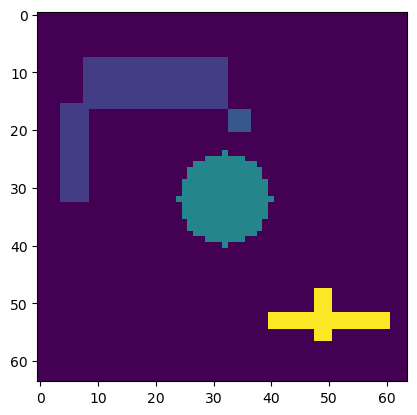

In [199]:
plt.imshow(connected_image_n4)
plt.show()

In [201]:
# Apply the equivalence graph to your components image with N8 Neighborhood and visualize your result
K, connected_image_n8 = equivalence_graph(im_bw,8)

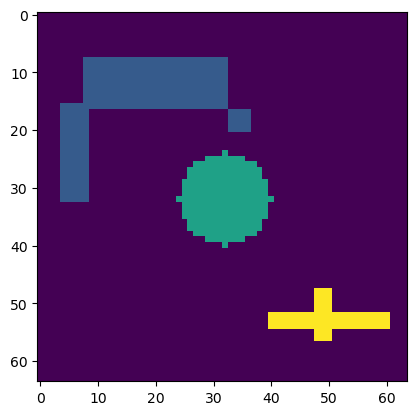

In [203]:
plt.imshow(connected_image_n8)
plt.show()

In [207]:
# Print the number of components in the binary image for N4 Neighborhood and N8 Neighborhood
c_n4 = len(np.unique(connected_image_n4)) -1 # -1 is necessary to exclude background
c_n8 = len(np.unique(connected_image_n8)) - 1 # -1 is necessary to exclude the background
print ('number of components using N4 neighborhood: ', c_n4)
print ('number of components using N8 neighborhood: ', c_n8)

number of components using N4 neighborhood:  4
number of components using N8 neighborhood:  3


If there is any difference in the number of components explains why this is the case:<br>
*There are 4 components using N4 neighborhood while there are 3 components using N8 neighborhood. The difference is due to the difference in the connectivity in the image.*

## B. Morphological Operations and Distance Transformation *(12 points)*

In the lecture your discussed *Morphological Operators* to expand and shrink the foreground of binary images as well as the *Distance Transformation* to compute the distance from any pixel to the border of the components.

**Tasks:**
1. Implement the *Distance Transformation* algorithm and apply it to the previous defined binary image (*A2*) by following each step outlined below:
    - Write a function called ```distance_transformation(binary_img, neighborhood)``` which computes the *distance image* for either *N4 neighborhood* or *N8 neighborhood*. Do not use any external python functions which compute the *distance image* for you. *(5 points)*
    - Apply your function to the binary image and visualize your result for *N4 neighborhood* and *N8 neighborhood*. *(2 points)*
    
2. Apply a *Dilation* to the binary image by using the the ```skimage.morphology``` module ([link](https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.dilation))
    - Follow the steps provided by the [example](https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.dilation) to dilate the binary image *(2 points)*
    - Visualize your results and describe your observations *(1 point)*
    
3. Finally, apply the *Distance Transformation* with N4 neighborhood to the dilated binary image and visualize your result. *(2 points)*

### B1

In [41]:
# Write a function called distance_transformation(binary_img, neighborhood) to compute the distance matrix

def distance_transformation(binary_img, neighborhood):

    distance_image = np.zeros(np.shape(binary_img)) # image to get output as distance image

    for row in range(np.shape(binary_img)[0]): # loop over the image rows
        for col in range(np.shape(binary_img)[1]): # loop over the image columns

            if binary_img[row,col] == 1: # check if it's a foreground pixel

                if neighborhood == 4: # if we are considering 4 neighbors

                    row_up = row # saving row number to process for neighbors in the upward direction
                    col_up = col # saving column number to process for neighbors in the upward direction
                    dist_up = 0 # distance in the upward direction

                    row_left = row # saving row number to process for neighbors in the left direction
                    col_left = col # saving column number to process for neighbors in the left direction
                    dist_left = 0 # distance in the left direction

                    while row_up - 1 >= 0 and binary_img[row_up,col_up] == 1: # go in the upward direction until we reach end of neighbors or we hit a background pixel

                        row_up -= 1 # move upwards 
                        dist_up += 1 # add a pixel as a distance to the background

                    while col_left - 1 >= 0 and binary_img[row_left,col_left] == 1: # go in the left direction until we reach end of neighbors or we hit a background pixel

                        col_left -= 1 # move left
                        dist_left += 1 # add a pixel as a distance to the background

                    if dist_left < dist_up: # assign distance from left if it is shorter else assign distance from the top

                        distance_image[row,col] = dist_left

                    else:

                        distance_image[row,col] = dist_up

                if neighborhood == 8: # if we are considering 8 neighbors

                    row_up = row # saving row number to process for neighbors in the upward direction
                    col_up = col # saving column number to process for neighbors in the upward direction
                    dist_up = 0 # distance in the upward direction

                    row_left = row # saving row number to process for neighbors in the left direction
                    col_left = col # saving column number to process for neighbors in the left direction
                    dist_left = 0 # distance in the left direction

                    row_left_diagonal = row # saving row number to process for neighbors in the left diagonal direction
                    col_left_diagonal = col # saving column number to process for neighbors in the left diagonal direction
                    dist_left_diagonal = 0 # distance in the left diagonal direction

                    row_right_diagonal = row # saving row number to process for neighbors in the right diagonal direction
                    col_right_diagonal = col # saving column number to process for neighbors in the right diagonal direction
                    dist_right_diagonal = 0 # distance in the right diagonal direction

                    while row_up - 1 >= 0 and binary_img[row_up,col_up] == 1: # go in the upward direction until we reach end of neighbors or we hit a background pixel

                        row_up -= 1 # move upwards 
                        dist_up += 1 # add a pixel as a distance to the background

                    while col_left - 1 >= 0 and binary_img[row_left,col_left] == 1: # go in the left direction until we reach end of neighbors or we hit a background pixel

                        col_left -= 1 # move left
                        dist_left += 1 # add a pixel as a distance to the background

                    while row_left_diagonal - 1 >= 0 and col_left_diagonal - 1 >= 0 and binary_img[row_left_diagonal,col_left_diagonal] == 1: # go in the left diagonal direction until we reach end of neighbors or we hit a background pixel

                        row_left_diagonal -= 1 # move left diagonal
                        col_left_diagonal -= 1 # move left diagonal
                        dist_left_diagonal += 1 # add a pixel as a distance to the background

                    while row_right_diagonal - 1 >= 0 and col_right_diagonal + 1 < np.shape(binary_img)[1] and binary_img[row_right_diagonal,col_right_diagonal] == 1: # go in the right diagonal direction until we reach end of neighbors or we hit a background pixel

                        row_right_diagonal -= 1 # move right diagonal
                        col_right_diagonal += 1 # move right diagonal
                        dist_right_diagonal += 1 # add a pixel as a distance to the background


                    distance_image[row,col] = min([dist_up, dist_left, dist_left_diagonal, dist_right_diagonal]) # assign the minimum distance to the current pixel location


    for row in range(np.shape(binary_img)[0]-1,-1,-1): # loop over the image rows in reverse order
        for col in range(np.shape(binary_img)[1]-1,-1,-1): # loop over the image columns in reverse order

            if binary_img[row,col] == 1: # check if it's a foreground pixel

                if neighborhood == 4: # if we are considering 4 neighbors

                    row_down = row # saving row for processing neighbors in the down direction
                    col_down = col # saving column for processing neighbors in the down direction
                    dist_down = 0 # distance in the down direction

                    row_right = row # saving row for processing neighbors in the right direction
                    col_right = col # saving column for processing neighbors in the right direction
                    dist_right = 0 # distance in the right direction

                    while row_down + 1 < np.shape(binary_img)[0] and binary_img[row_down,col_down] == 1: # go in the down direction until we reach end of neighbors or we hit a background pixel

                        row_down += 1 # move down
                        dist_down += 1 # add a pixel as a distance to the background

                    while col_right + 1 < np.shape(binary_img)[1] and binary_img[row_right,col_right] == 1: # go in the right direction until we reach end of neighbors or we hit a background pixel
                        
                        col_right += 1 # move right
                        dist_right += 1 # add a pixel as a distance to the background

                    distance_image[row,col] = min([dist_down, dist_right, distance_image[row,col]]) # assign the minimum distance to the current pixel location

                if neighborhood == 8: # if we are considering 8 neighbors

                    row_down = row # saving row for processing neighbors in the down direction
                    col_down = col # saving column for processing neighbors in the down direction
                    dist_down = 0 # distance in the down direction

                    row_right = row # saving row for processing neighbors in the right direction
                    col_right = col # saving column for processing neighbors in the right direction
                    dist_right = 0 # distance in the right direction

                    row_down_right_diagonal = row # saving row for processing neighbors in the down right diagonal direction
                    col_down_right_diagonal = col # saving column for processing neighbors in the down right diagonal direction
                    dist_down_right_diagonal = 0 # distance in the down right diagonal direction

                    row_down_left_digonal = row # saving row for processing neighbors in the down left diagonal direction
                    col_down_left_diagonal = col # saving column for processing neighbors in the down left diagonal direction
                    dist_down_left_diagonal = 0 # distance in the down left diagonal direction

                    while row_down + 1 < np.shape(binary_img)[0] and binary_img[row_down,col_down] == 1: # go in the down direction until we reach end of neighbors or we hit a background pixel

                        row_down += 1 # move down
                        dist_down += 1 # add a pixel as a distance to the background

                    while col_right + 1 < np.shape(binary_img)[1] and binary_img[row_right,col_right] == 1: # go in the right direction until we reach end of neighbors or we hit a background pixel
                        
                        col_right += 1 # move right
                        dist_right += 1 # add a pixel as a distance to the background

                    while row_down_right_diagonal + 1 < np.shape(binary_img)[0] and col_down_right_diagonal + 1 < np.shape(binary_img)[1] and binary_img[row_down_right_diagonal,col_down_right_diagonal] == 1:  # go in the down right diagonal direction until we reach end of neighbors or we hit a backgraound pixel 

                        row_down_right_diagonal += 1 # move down right diagonal
                        col_down_right_diagonal += 1 # move down right diagonal
                        dist_down_right_diagonal += 1 # add a pixel as a distance to the background

                    while row_down_left_digonal + 1 < np.shape(binary_img)[0] and col_down_left_diagonal - 1 >= 0 and binary_img[row_down_left_digonal,col_down_left_diagonal] == 1: # go in the down left diagonal direction until we reach end of neighbors or we hit a background pixel

                        row_down_left_digonal += 1 # move down left diagonal
                        col_down_left_diagonal -= 1 # move down left diagonal
                        dist_down_left_diagonal += 1 # add a pixel as a distance to the background

                    distance_image[row,col] = min([dist_down, dist_right, dist_down_right_diagonal, dist_down_left_diagonal, distance_image[row,col]]) # assign the minimum distance to the current pixel location
                        
    return distance_image
                            
                    

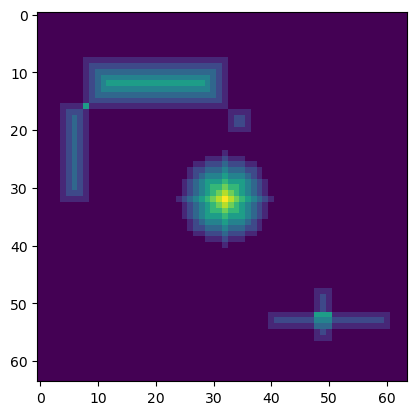

In [47]:
# Compute the distance matrix with N4 Neighborhood and visualize your result
distance_image = distance_transformation(im_bw,4)
plt.imshow(distance_image)
plt.show()

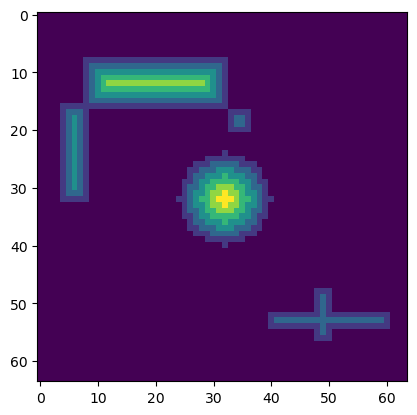

In [49]:
# Compute the distance matrix with N8 Neighborhood and visualize your result
distance_image = distance_transformation(im_bw,8)
plt.imshow(distance_image)
plt.show()

### B2

In [67]:
# Apply a Dilation to the binary image
dilated_img = skimage.morphology.dilation(im_bw)

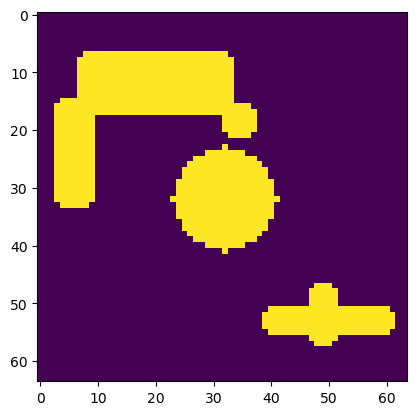

In [69]:
# Visualize the dilated binary image
plt.imshow(dilated_img)
plt.show()

**Explain your observations here**

The object boundaries have been expanded

### B3

In [77]:
# Compute the distance matrix with N4 Neighborhood of the dilated binary image
distance_image = distance_transformation(dilated_img,4)

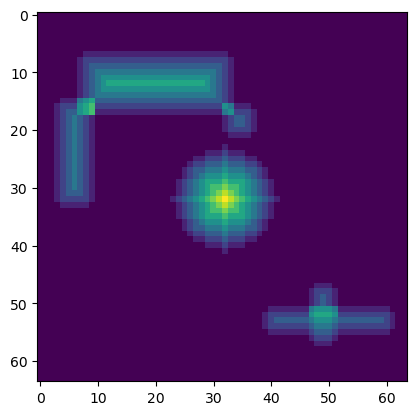

In [79]:
# Visualze the corresponding distance matrix
plt.imshow(distance_image)
plt.show()